# Quality Control Exploration Using Xarray

In [1]:
import datetime
import numpy as np
import pandas as pd
from pathlib import Path

import pyearthtools.pipeline as petpipe
import pyearthtools.data as petdata
from pyearthtools.tutorial.HadisdDataClass import HadISDIndex

In [2]:
varname_val_map = {
        "total_cloud_cover": -999., 
        "low_cloud_cover": -999., 
        "mid_cloud_cover": -999.,
        "high_cloud_cover": -999.,
        "winddirs": -999.
    }

flagged_labels = [
        'temperatures', 'dewpoints', 'slp',
        'stnlp', 'windspeeds', 'winddirs', 
        'total_cloud_cover', 'low_cloud_cover', 'mid_cloud_cover', 
        'high_cloud_cover', 'precip1_depth', 'precip2_depth', 
        'precip3_depth', 'precip6_depth', 'precip9_depth',
        'precip12_depth', 'precip15_depth', 'precip18_depth', 
        'precip24_depth'
    ]

# Creation of Custom PipelineSteps 
TODO: Move these to a new home once new structure is thought about

In [3]:
# Custom operation to remove redundent coordinates
# TODO: Find a home for this in pyearthtools and refine logic
class SqueezeStationCoordinates(petpipe.Operation):
    def __init__(self, coords=("latitude", "longitude", "elevation")):
        super().__init__()
        self.coords = coords
    def apply_func(self, ds):
        for coord in self.coords:
            if coord in ds.coords and len(ds[coord].shape) > 1:
                ds[coord] = ds[coord].squeeze()
        return ds
    
    # Undo function added otherwise pyearthtools will complain
    def undo_func(self, ds):
        # No undo operation needed for this operation
        return ds

In [4]:
# Custom operation split data into feature and target variables
# TODO: Find a home for this in pyearthtools and refine logic
class FeatureTargetSplit(petpipe.Operation):
    """
    Split dataset into features (X) and target (y) for ML.
    """
    def __init__(self, target_vars, drop_target_from_x=True):
        super().__init__()
        self.target_vars = [target_vars] if isinstance(target_vars, str) else list(target_vars)
        self.drop_target_from_x = drop_target_from_x

    def apply_func(self, ds):
        # X: all variables except target(s)
        if self.drop_target_from_x:
            feature_vars = [v for v in ds.data_vars if v not in self.target_vars]
        else:
            feature_vars = list(ds.data_vars)
        X = ds[feature_vars]
        # y: just the target(s)
        y = ds[self.target_vars]
        return (X, y)
    
    # Undo function added otherwise pyearthtools will complain
    def undo_func(self, ds):
        return ds

# Create an ordered list of all available HadISD station IDs
The  HadISDIndex class contains a method called "get_alL station_ids" that can be used to create a list of all available station IDS. This list can be used to select, for example, the first_ten stations from all stations. It can then be passed used to select data from within the pipeline. It's also possible to pass a single station ID as a string to retrieve data for a single station.

TODO:
- It would be good if a range of stations can be provided, or a boundary with stations inside

In [6]:
hadisd = HadISDIndex()
all_stations = hadisd.get_all_station_ids(Path("/Users/joelmiller/Projects/data/hadisd"))
all_stations_ordered = sorted(all_stations)
print(f"Total number of stations: {len(all_stations_ordered)}")
first_ten_stations = all_stations_ordered[:10]
print(first_ten_stations)

Total number of stations: 1529
['010010-99999', '010014-99999', '010030-99999', '010070-99999', '010080-99999', '010100-99999', '010150-99999', '010230-99999', '010250-99999', '010260-99999']


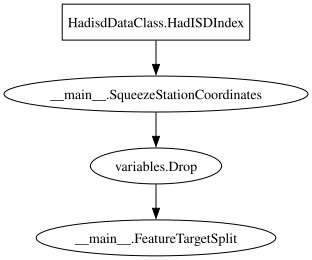

In [7]:
# Hadisd accepts "all" as an argument to get all stations.
# A single station can also be specified, e.g. "010010-99999".
# Or, a list of station IDs can be passed.

# TODO: Make numpy conversion step work. Add functionality for selecting rang, selecting nearest neigbours, etc
data_prep_pipe = petpipe.Pipeline(
    petdata.archive.hadisd(station = first_ten_stations), #, variables = ["total_cloud_cover", "temperatures", "flagged_obs"]), # Commented out variable selection whilst looking into bug in BaseTransforms
    SqueezeStationCoordinates(), # Squeeze coordinates to 1D if they are 2D: Remove redundant dimensions
    petdata.transforms.variables.Drop("flagged_obs"), # Drop the flagged_obs variable as it is not needed for ML an might even introduce bias
    FeatureTargetSplit(target_vars="quality_control_flags"), # Split dataset into features and target variable
)
data_prep_pipe

In [8]:
x, y = data_prep_pipe["1969-01-01T07"]
y

/Users/joelmiller/Projects/Python/PyEarthTools_Fork/PyEarthTools/packages/data/src/pyearthtools/data/indexes/indexes.py:492: IndexWarning: Could not find time in dataset to select on. Petdt('1969-01-01T07')
  warnings.warn(


<xarray.Dataset> Size: 3GB
Dimensions:                (station: 10, time: 473352, test: 71)
Coordinates:
    station_id             (station) <U12 480B '010010-99999' ... '010260-99999'
  * time                   (time) datetime64[ns] 4MB 1970-01-01 ... 2023-12-3...
Dimensions without coordinates: station, test
Data variables:
    quality_control_flags  (station, time, test) float64 3GB dask.array<chunksize=(1, 29585, 5), meta=np.ndarray>
Attributes: (12/39)
    Conventions:                 CF-1.6
    Metadata_Conventions:        Unidata Dataset Discovery v1.0, CF Discrete ...
    acknowledgement:             RJHD was supported by the Joint BEIS/Defra M...
    cdm_data_type:               station
    creator_email:               robert.dunn@metoffice.gov.uk
    creator_name:                Robert Dunn
    ...                          ...
    station_id:                  010010-99999
    station_information:         Where station is a composite the station id ...
    summary:                     Quality-controlled, sub-daily, station datas...
    time_coverage_end:           2023-12-31T23:00Z
    time_coverage_start:         1931-01-01T06:00Z
    title:                       HadISD

In [9]:
qc = y["quality_control_flags"].values
qc

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       ...,

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan

In [ ]:
# Suppose you want test 0:
qc_test_0 = qc[:, :, 0]  # shape: (station, time)
qc_df = pd.DataFrame(qc_test_0, index=y["quality_control_flags"].coords["station"].values, columns=x.time.values)
qc_df.head()

In [ ]:
# Convert to pandas DataFrame for easier manipulation
qc_df = pd.DataFrame(qc, columns=y["quality_control_flags"].dims[1:], index=x.time.values)
# Display the first few rows of the DataFrame
qc_df.head()

In [10]:
print("Unique QC flag values:", np.unique(qc[~np.isnan(qc)]))
print("QC flag shape:", qc.shape)

Unique QC flag values: [-1.  0.  1.  2.]
QC flag shape: (10, 473352, 71)


In [11]:
for i in range(qc.shape[2]):  # for each test
    unique_vals = np.unique(qc[:, :, i][~np.isnan(qc[:, :, i])])
    print(f"Test {i}: unique QC flag values: {unique_vals}")

Test 0: unique QC flag values: [0.]
Test 1: unique QC flag values: [0.]
Test 2: unique QC flag values: [0.]
Test 3: unique QC flag values: [0.]
Test 4: unique QC flag values: [0.]
Test 5: unique QC flag values: [0. 1.]
Test 6: unique QC flag values: [0. 1.]
Test 7: unique QC flag values: [0. 1. 2.]
Test 8: unique QC flag values: [0.]
Test 9: unique QC flag values: [0.]
Test 10: unique QC flag values: [0.]
Test 11: unique QC flag values: [0.]
Test 12: unique QC flag values: [0. 1.]
Test 13: unique QC flag values: [0. 1.]
Test 14: unique QC flag values: [0. 1.]
Test 15: unique QC flag values: [0. 1.]
Test 16: unique QC flag values: [0.]
Test 17: unique QC flag values: [0.]
Test 18: unique QC flag values: [0.]
Test 19: unique QC flag values: [0.]
Test 20: unique QC flag values: [0.]
Test 21: unique QC flag values: [0.]
Test 22: unique QC flag values: [0.]
Test 23: unique QC flag values: [0.]
Test 24: unique QC flag values: [0. 1. 2.]
Test 25: unique QC flag values: [0. 1. 2.]
Test 26: uni

In [12]:
# Sum of flags per test (across all stations and times)
qc_sum_per_test = np.nansum(qc, axis=(0, 1))
print("QC fails per test:", qc_sum_per_test)

# Sum per station
qc_sum_per_station = np.nansum(qc, axis=(1, 2))
print("QC fails per station:", qc_sum_per_station)

QC fails per test: [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
  5.20000e+01  8.50000e+01  1.00000e+01  0.00000e+00  0.00000e+00
  0.00000e+00  0.00000e+00  1.11350e+04  1.13350e+04  5.86000e+02
  4.90000e+01  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  4.93000e+02
  1.14400e+03  0.00000e+00  4.66000e+02  3.88000e+02  1.00000e+02
  0.00000e+00  1.62200e+03  1.33000e+03  7.07060e+04  6.45470e+04
  1.80000e+01  2.10000e+01  1.77630e+04  1.59900e+03  6.00000e+00
  0.00000e+00 -9.40000e+01 -4.20000e+01 -3.15000e+02  1.58700e+03
  1.90400e+03  7.71000e+02  5.78600e+03  5.78000e+03  0.00000e+00
  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  1.80000e+02
  1.91000e+02  5.61000e+02  5.26000e+02  1.02100e+03  5.93000e+02
  0.00000e+00  1.48000e+03  0.00000e+00 -1.38633e+05  8.31100e+03
  2.62000e+02  3.35600e+03  0.00000e+00  0.00000e+00  2.37700e+03
  8.60000e+02]
QC fails per station: [ 21045.   2553.    

In [13]:
for i in range(0, 71):
    failed = np.where(qc[:, :, i] == 1)
    print(f"Stations with fails for test {i}:", failed[0])
    print(f"Times with fails for test {i}:", failed[1])


Stations with fails for test 0: []
Times with fails for test 0: []
Stations with fails for test 1: []
Times with fails for test 1: []
Stations with fails for test 2: []
Times with fails for test 2: []
Stations with fails for test 3: []
Times with fails for test 3: []
Stations with fails for test 4: []
Times with fails for test 4: []
Stations with fails for test 5: [0 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4
 5 5 5 5 5 5 6 6 6 6 6 7 8 8 8]
Times with fails for test 5: [181050 154061 155949 159283 159287 159477 159515 159627 203789 135187
 135582 151782 197025 197886 207114 215469 215619 218910 224232 276486
  29736  44319 125140 125638 127080 144529 152166 162888 192252 251121
 273666 283608 287556 309916 389109 389115  91662  92325  95140 209038
 209039 237983 456689 164946 172794 195150 227070 227742  95887  90278
  90279 216868]
Stations with fails for test 6: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 

In [ ]:
# Stations with fails for test 12: [0]
# Times with fails for test 12: [826]

# for qc, test 12, time 826, station 0, print the value of the test
print("QC value for test 12, time 826, station 0:", qc[0, 826, 12])